# Zadanie 1: Przewidywanie zanieczyszczeń powietrza (PM2.5) — LSTM

## 0. Importy bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

import warnings
warnings.filterwarnings('ignore')

# Reprodukowalność
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

TensorFlow: 2.17.0
Keras: 3.4.1


---
## Krok 1 - Wczytanie i wstępne przetworzenie danych

In [2]:
# Wczytanie danych — pomijamy kolumny No, wd, station
df = pd.read_csv(
    'PRSA_Data_Wanshouxigong_20130301-20170228.csv',
    usecols=lambda col: col not in ['No', 'wd', 'station']
)

print('Kształt wczytanej ramki:', df.shape)
df.head()

Kształt wczytanej ramki: (35064, 15)


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
0,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,2.0
1,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,4.4
2,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,4.7
3,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,2.6
4,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,2.5


In [3]:
# Łączenie kolumn year, month, day, hour w jeden indeks datetime
df['Date'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']].rename(
        columns={'year': 'year', 'month': 'month', 'day': 'day', 'hour': 'hour'}
    )
)
df.set_index('Date', inplace=True)
df.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)

print('Kształt ramki po przekształceniu:', df.shape)
print('Zakres dat:', df.index.min(), '—', df.index.max())
df.head()

Kształt ramki po przekształceniu: (35064, 11)
Zakres dat: 2013-03-01 00:00:00 — 2017-02-28 23:00:00


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
Date,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,2.0
2013-03-01 01:00:00,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,4.4
2013-03-01 02:00:00,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,4.7
2013-03-01 03:00:00,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,2.6
2013-03-01 04:00:00,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,2.5


In [4]:
# Interpretacja zmiennych
print('Kolumny i typy danych:')
print(df.dtypes)
print()
print("""
Interpretacja kolumn:
  PM2.5  — stężenie pyłu PM2.5 [µg/m³] — ZMIENNA CELU
  PM10   — stężenie pyłu PM10 [µg/m³]
  SO2    — stężenie dwutlenku siarki [µg/m³]
  NO2    — stężenie dwutlenku azotu [µg/m³]
  CO     — stężenie tlenku węgla [µg/m³]
  O3     — stężenie ozonu [µg/m³]
  TEMP   — temperatura powietrza [°C]
  PRES   — ciśnienie atmosferyczne [hPa]
  DEWP   — temperatura punktu rosy [°C]
  RAIN   — opady [mm]
  WSPM   — prędkość wiatru [m/s]
""")

Kolumny i typy danych:
PM2.5    float64
PM10     float64
SO2      float64
NO2      float64
CO       float64
O3       float64
TEMP     float64
PRES     float64
DEWP     float64
RAIN     float64
WSPM     float64
dtype: object


Interpretacja kolumn:
  PM2.5  — stężenie pyłu PM2.5 [µg/m³] — ZMIENNA CELU
  PM10   — stężenie pyłu PM10 [µg/m³]
  SO2    — stężenie dwutlenku siarki [µg/m³]
  NO2    — stężenie dwutlenku azotu [µg/m³]
  CO     — stężenie tlenku węgla [µg/m³]
  O3     — stężenie ozonu [µg/m³]
  TEMP   — temperatura powietrza [°C]
  PRES   — ciśnienie atmosferyczne [hPa]
  DEWP   — temperatura punktu rosy [°C]
  RAIN   — opady [mm]
  WSPM   — prędkość wiatru [m/s]



---
## Krok 2 — Eksploracyjna analiza danych (EDA)

In [5]:
# Statystyki opisowe
df.describe().round(2)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.00,34580.00,34395.00,34310.00,33767.00,33986.00,35045.00,35045.00,35045.00,35045.00,35051.00
mean,85.02,112.22,17.15,55.53,1370.40,56.23,13.78,1011.51,2.71,0.06,1.75
std,85.98,97.59,23.94,35.81,1223.14,57.08,11.39,10.57,13.70,0.80,1.21
min,3.00,2.00,0.29,2.00,100.00,0.21,-16.80,985.10,-35.30,0.00,0.00
25%,23.00,39.00,3.00,28.00,600.00,8.00,3.40,1002.80,-8.50,0.00,0.90
50%,60.00,91.00,8.00,49.00,1000.00,42.00,14.80,1011.00,3.30,0.00,1.40
75%,116.00,154.00,21.00,77.00,1700.00,82.00,23.50,1020.00,15.20,0.00,2.30
max,999.00,961.00,411.00,251.00,9800.00,358.00,40.60,1042.00,28.50,46.40,13.20


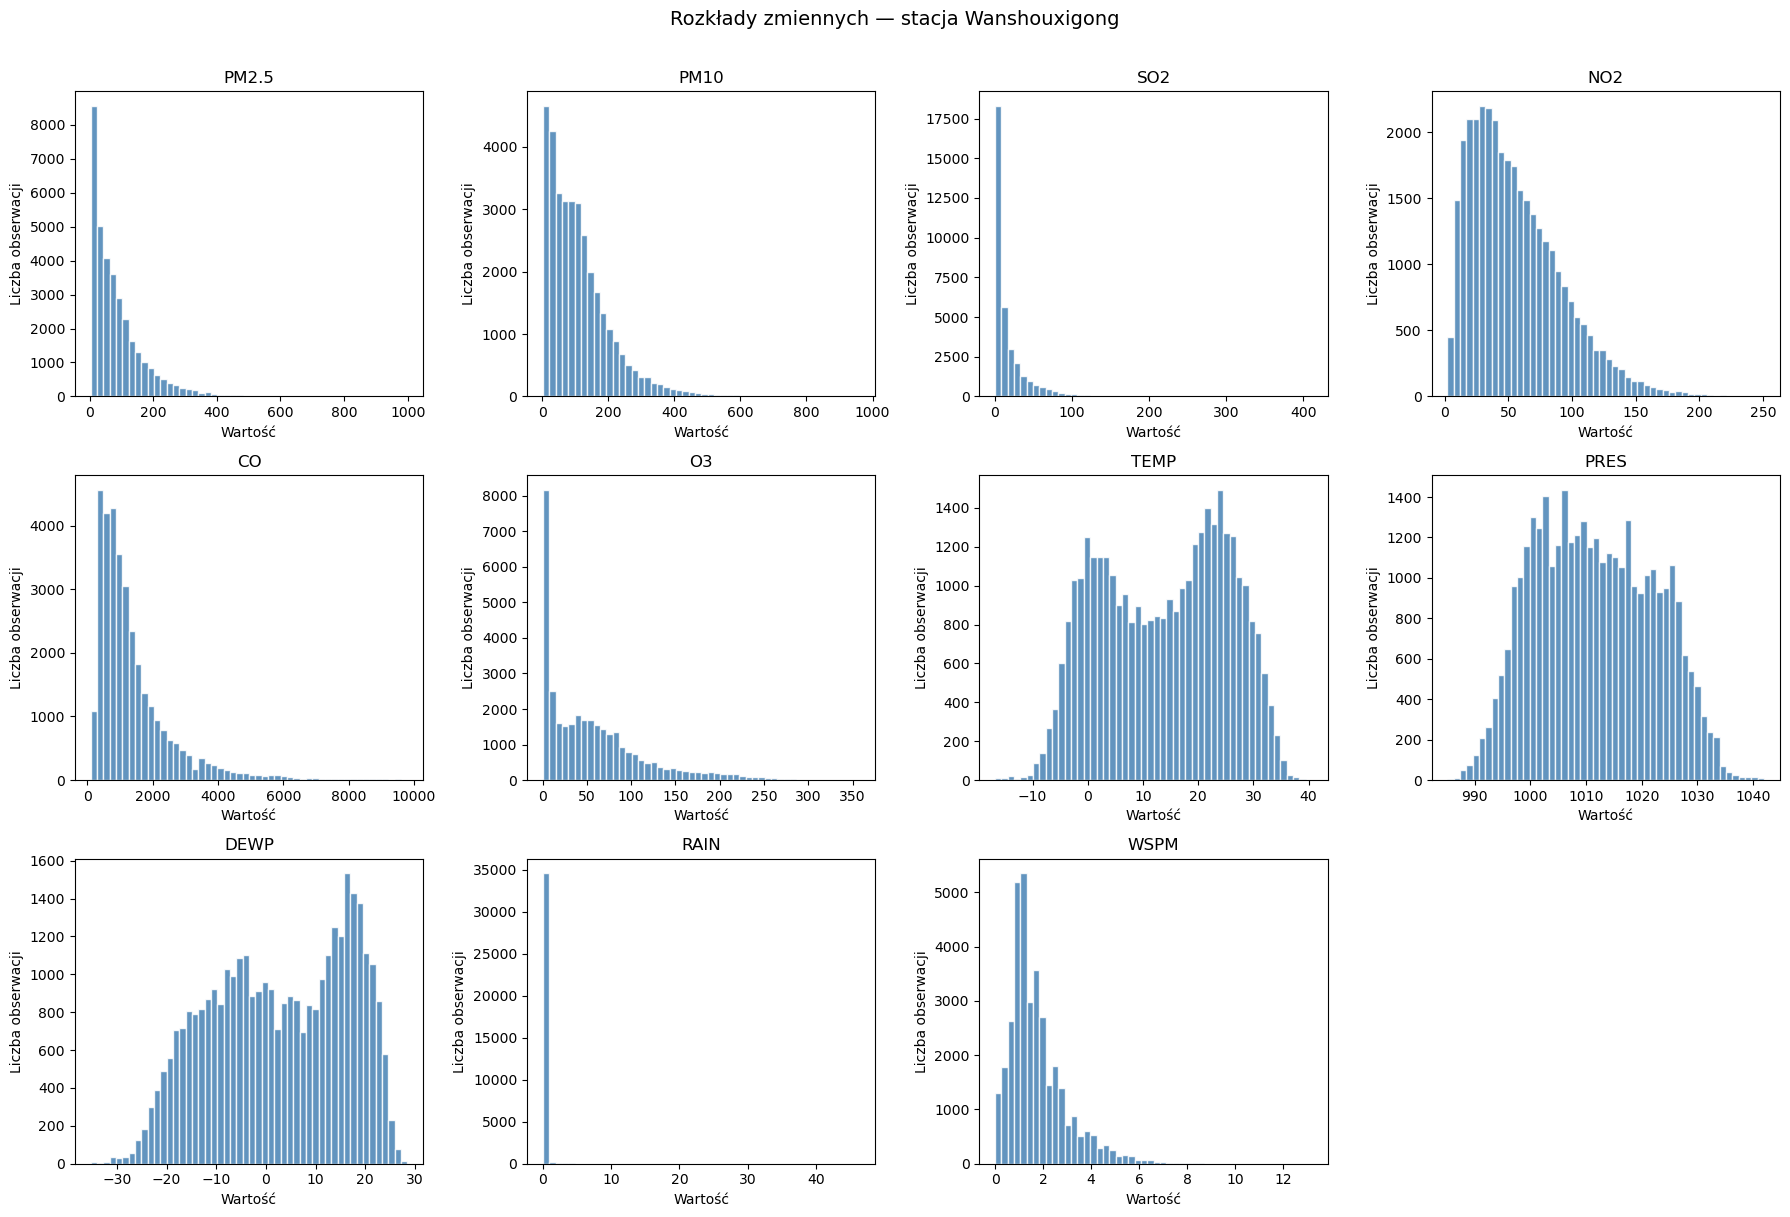

In [6]:
# Rozkłady zmiennych
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Wartość')
    axes[i].set_ylabel('Liczba obserwacji')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Rozkłady zmiennych — stacja Wanshouxigong', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('rozkłady.png', dpi=120, bbox_inches='tight')
plt.show()

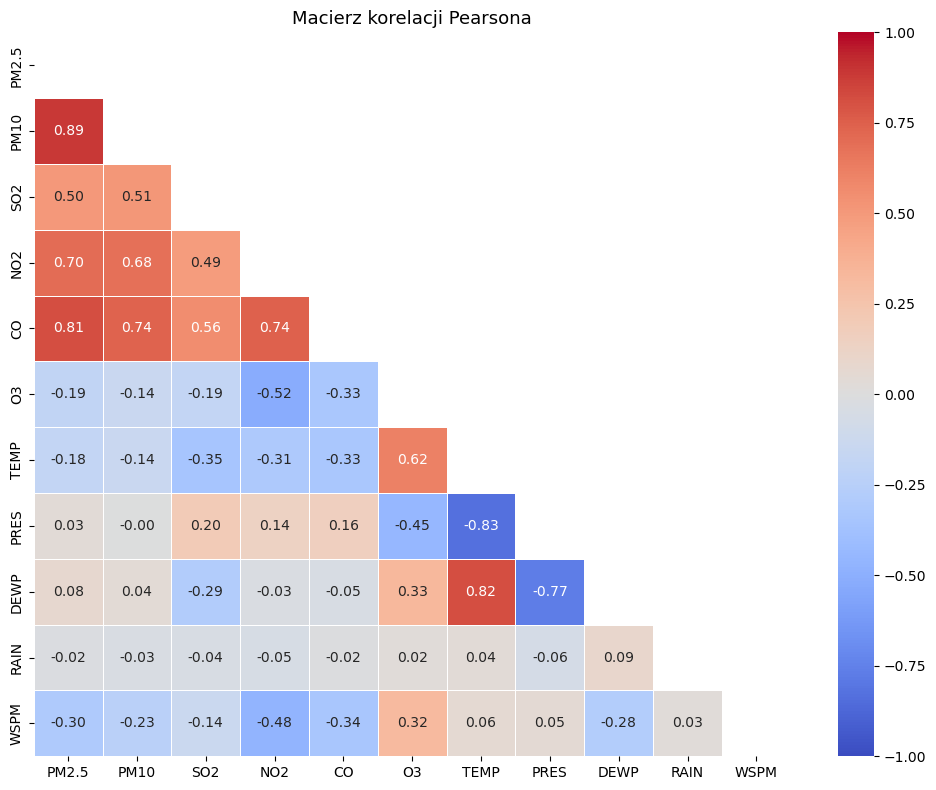

In [7]:
# Macierz korelacji
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Macierz korelacji Pearsona', fontsize=13)
plt.tight_layout()
plt.savefig('korelacje.png', dpi=120, bbox_inches='tight')
plt.show()

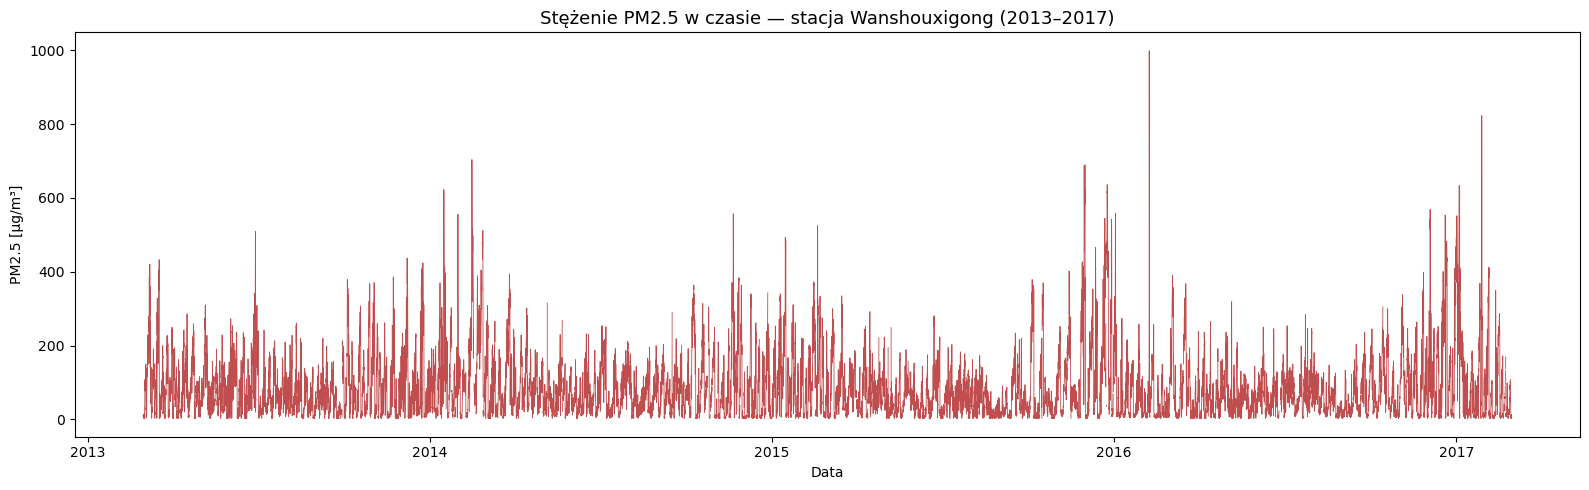

In [8]:
# Szereg czasowy PM2.5
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['PM2.5'], color='firebrick', linewidth=0.6, alpha=0.8)
ax.set_title('Stężenie PM2.5 w czasie — stacja Wanshouxigong (2013–2017)', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('PM2.5 [µg/m³]')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('pm25_czas.png', dpi=120, bbox_inches='tight')
plt.show()

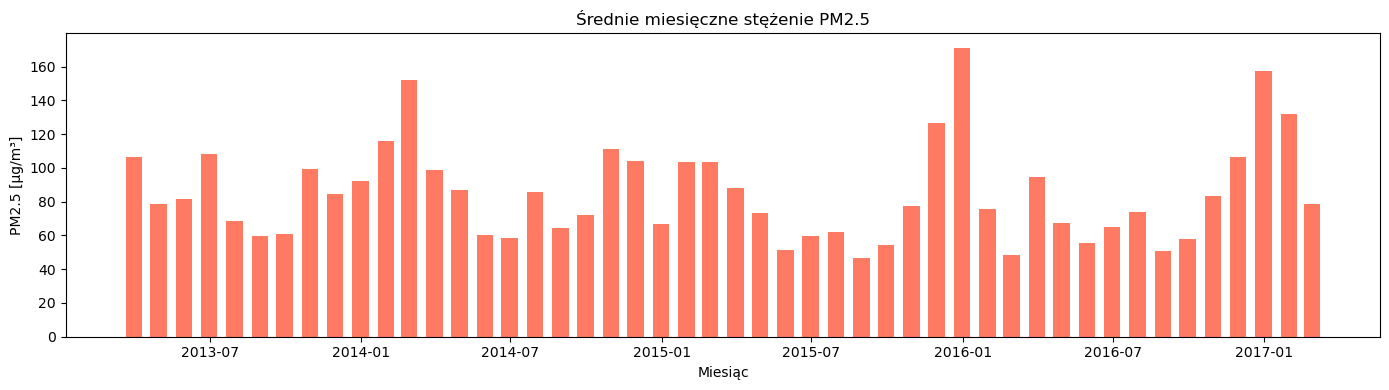

In [9]:
# Sezonowość — średnia miesięczna PM2.5
monthly_avg = df['PM2.5'].resample('ME').mean()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_avg.index, monthly_avg.values, width=20, color='tomato', alpha=0.85)
ax.set_title('Średnie miesięczne stężenie PM2.5', fontsize=12)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('PM2.5 [µg/m³]')
plt.tight_layout()
plt.show()

---
## Krok 3 — Braki danych i imputacja

       Braki  Procent [%]
CO      1297         3.70
O3      1078         3.07
NO2      754         2.15
PM2.5    696         1.98
SO2      669         1.91
PM10     484         1.38
TEMP      19         0.05
PRES      19         0.05
DEWP      19         0.05
RAIN      19         0.05
WSPM      13         0.04


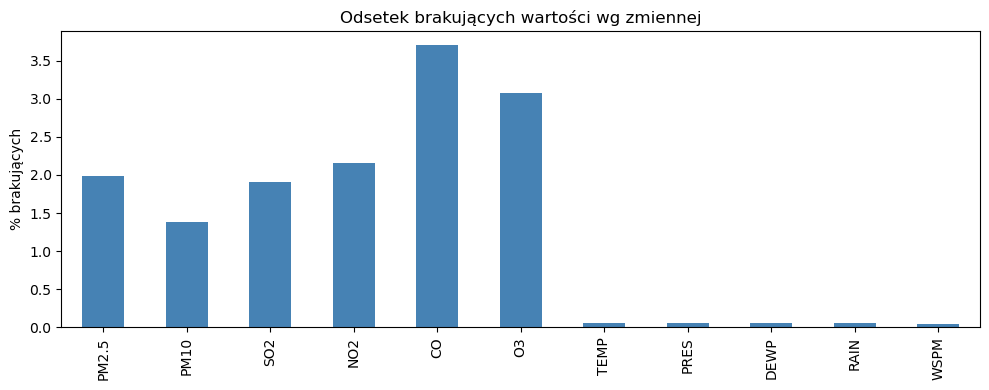

In [10]:
# Analiza braków danych
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Braki': missing, 'Procent [%]': missing_pct})
print(miss_df[miss_df['Braki'] > 0].sort_values('Braki', ascending=False))

# Wizualizacja braków
fig, ax = plt.subplots(figsize=(10, 4))
miss_df[miss_df['Braki'] > 0]['Procent [%]'].plot.bar(color='steelblue', ax=ax)
ax.set_title('Odsetek brakujących wartości wg zmiennej')
ax.set_ylabel('% brakujących')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [11]:
# Usunięcie wierszy z brakującą zmienną celu PM2.5
print(f'Rozmiar przed usunięciem braków PM2.5: {len(df)}')
df = df.dropna(subset=['PM2.5'])
print(f'Rozmiar po usunięciu:                  {len(df)}')

Rozmiar przed usunięciem braków PM2.5: 35064
Rozmiar po usunięciu:                  34368


In [12]:
# Interpolacja liniowa dla pozostałych zmiennych
# Upewniamy się, że indeks jest posortowany (dane godzinowe)
df = df.sort_index()
df_interpolated = df.interpolate(method='time', limit_direction='both')

# Sprawdzenie, czy pozostały jakieś braki
print('Braki po interpolacji:')
print(df_interpolated.isnull().sum())
df = df_interpolated

Braki po interpolacji:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


---
## Krok 4 — Podział danych i przygotowanie sekwencji czasowych

In [13]:
# Zmienna celu i zmienne wejściowe
y = df[['PM2.5']].values
X = df.drop(columns=['PM2.5']).values

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (34368, 10)
y shape: (34368, 1)


In [14]:
# Sekwencyjny podział 90% trening / 10% test (bez tasowania — szereg czasowy!)
split_idx = int(len(df) * 0.9)

X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train_raw = y[:split_idx]
y_test_raw  = y[split_idx:]

print(f'Trening: {X_train_raw.shape[0]} próbek ({split_idx})')
print(f'Test:    {X_test_raw.shape[0]} próbek')

Trening: 30931 próbek (30931)
Test:    3437 próbek


In [15]:
# Standaryzacja — WAŻNE: skalery dopasowujemy tylko na zbiorze treningowym!
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_test  = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_test  = scaler_y.transform(y_test_raw)

In [16]:
# Parametry generatora szeregów czasowych
WINDOW_SIZE = 24   # 24h okno uczące
BATCH_SIZE  = 128  # Najlepszy kompromis (eksperyment opisany w kroku 8)

train_gen = TimeseriesGenerator(
    X_train, y_train,
    length=WINDOW_SIZE,
    batch_size=BATCH_SIZE
)
test_gen = TimeseriesGenerator(
    X_test, y_test,
    length=WINDOW_SIZE,
    batch_size=BATCH_SIZE
)

print(f'Paczki treningowe: {len(train_gen)}')
print(f'Paczki testowe:    {len(test_gen)}')
x_batch, y_batch = train_gen[0]
print(f'Kształt paczki X: {x_batch.shape}  (batch, window, features)')
print(f'Kształt paczki y: {y_batch.shape}')

Paczki treningowe: 242
Paczki testowe:    27
Kształt paczki X: (128, 24, 10)  (batch, window, features)
Kształt paczki y: (128, 1)


---
## Krok 5 — Architektura modelu LSTM

In [17]:
n_features = X_train.shape[1]

def build_lstm_model(units=(128, 64, 32), dropout_rate=0.2):
    """Buduje model LSTM z konfigurowalnymi warstwami i dropoutem."""
    model = keras.Sequential()

    # Warstwa wejściowa (pseudowarstwa)
    model.add(keras.Input(shape=(WINDOW_SIZE, n_features)))

    # Warstwy LSTM
    for i, u in enumerate(units):
        return_seq = (i < len(units) - 1)  # ostatnia LSTM nie zwraca sekwencji
        model.add(layers.LSTM(u, return_sequences=return_seq))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Warstwa wyjściowa: 1 neuron, aktywacja liniowa
    model.add(layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=[keras.metrics.R2Score(name='r2')]
    )
    return model

model = build_lstm_model(units=(128, 64, 32), dropout_rate=0.2)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,025 (519.63 KB)

 Trainable params: 133,025 (519.63 KB)

 Non-trainable params: 0 (0.00 B)

---
## Krok 6 — Trenowanie modelu

In [18]:
# Callbacks: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint
cb_early = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    'best_lstm_pm25.keras', save_best_only=True, monitor='val_loss', verbose=0
)

EPOCHS = 60

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    callbacks=[cb_early, cb_lr, cb_ckpt],
    verbose=1
)

Epoch 1/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.4375 - r2: 0.4690 - val_loss: 0.4537 - val_r2: 0.7864 - learning_rate: 0.0010
Epoch 2/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.2959 - r2: 0.6933 - val_loss: 0.2992 - val_r2: 0.8592 - learning_rate: 0.0010
Epoch 3/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - loss: 0.1963 - r2: 0.7683 - val_loss: 0.2700 - val_r2: 0.8729 - learning_rate: 0.0010
Epoch 4/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.1794 - r2: 0.8259 - val_loss: 0.2127 - val_r2: 0.8999 - learning_rate: 0.0010
Epoch 5/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 0.1709 - r2: 0.8039 - val_loss: 0.3980 - val_r2: 0.8127 - learning_rate: 0.0010
Epoch 6/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.2084 - r2: 0.8033 - val_loss: 0.1793 - val_r2: 0.9156 - learning_rate: 0.0010
Epoch 7/60
242/242 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.1555 - r2: 0.8445 - val_loss: 0.2046 - val_r2: 0.9037 - learning_rate: 0.0010
Epoch 8/60
24

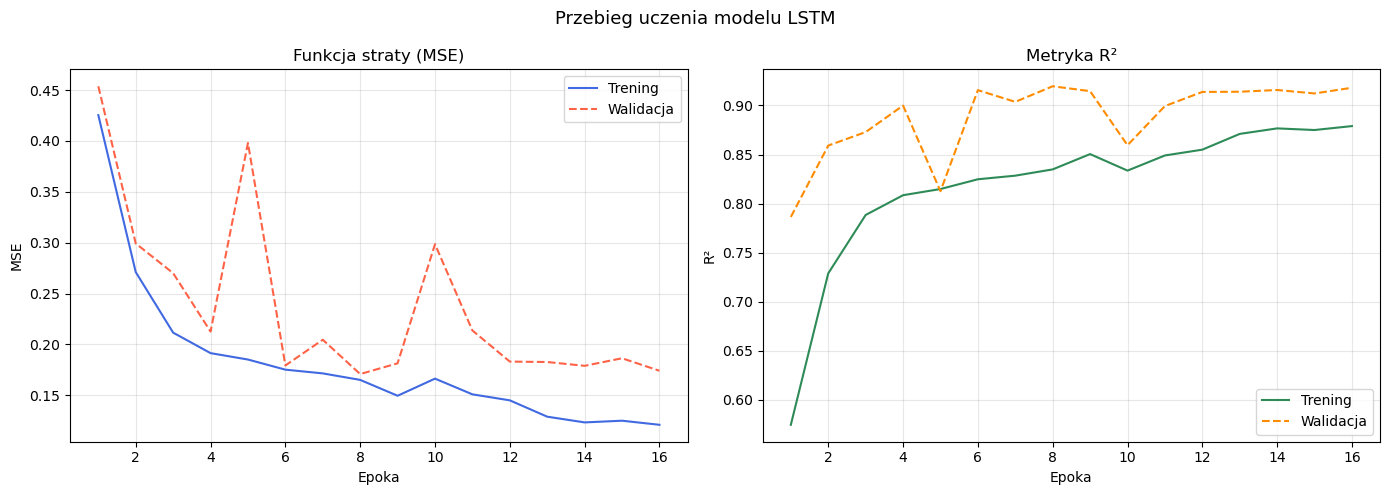

In [19]:
# Wizualizacja przebiegu uczenia
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strata (MSE)
axes[0].plot(epochs_ran, hist['loss'],     label='Trening',    color='royalblue')
axes[0].plot(epochs_ran, hist['val_loss'], label='Walidacja', color='tomato', linestyle='--')
axes[0].set_title('Funkcja straty (MSE)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Metryka R²
axes[1].plot(epochs_ran, hist['r2'],     label='Trening',    color='seagreen')
axes[1].plot(epochs_ran, hist['val_r2'], label='Walidacja', color='darkorange', linestyle='--')
axes[1].set_title('Metryka R²')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('R²')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Przebieg uczenia modelu LSTM', fontsize=13)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Krok 7 — Ocena jakości modelu

In [20]:
# Załadowanie najlepszego modelu
best_model = keras.models.load_model('best_lstm_pm25.keras')

# Predykcje (ze skalerowanej przestrzeni)
y_train_pred_scaled = best_model.predict(train_gen, verbose=0)
y_test_pred_scaled  = best_model.predict(test_gen,  verbose=0)

# Odwrotne skalowanie
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled)

# Wartości rzeczywiste (bez przesunięcia okna)
y_train_true = scaler_y.inverse_transform(y_train[WINDOW_SIZE:])
y_test_true  = scaler_y.inverse_transform(y_test[WINDOW_SIZE:])

In [21]:
# Metryki
mse_train = mean_squared_error(y_train_true, y_train_pred)
mse_test  = mean_squared_error(y_test_true,  y_test_pred)
r2_train  = r2_score(y_train_true, y_train_pred)
r2_test   = r2_score(y_test_true,  y_test_pred)

print('─' * 40)
print(f'  {'Zbiór':<12} {'MSE':>10}  {'R²':>8}')
print('─' * 40)
print(f'  {'Treningowy':<12} {mse_train:>10.2f}  {r2_train:>8.4f}')
print(f'  {'Testowy':<12} {mse_test:>10.2f}  {r2_test:>8.4f}')
print('─' * 40)

────────────────────────────────────────
  Zbiór               MSE        R²
────────────────────────────────────────
  Treningowy       834.07    0.8731
  Testowy         1122.66    0.9196
────────────────────────────────────────


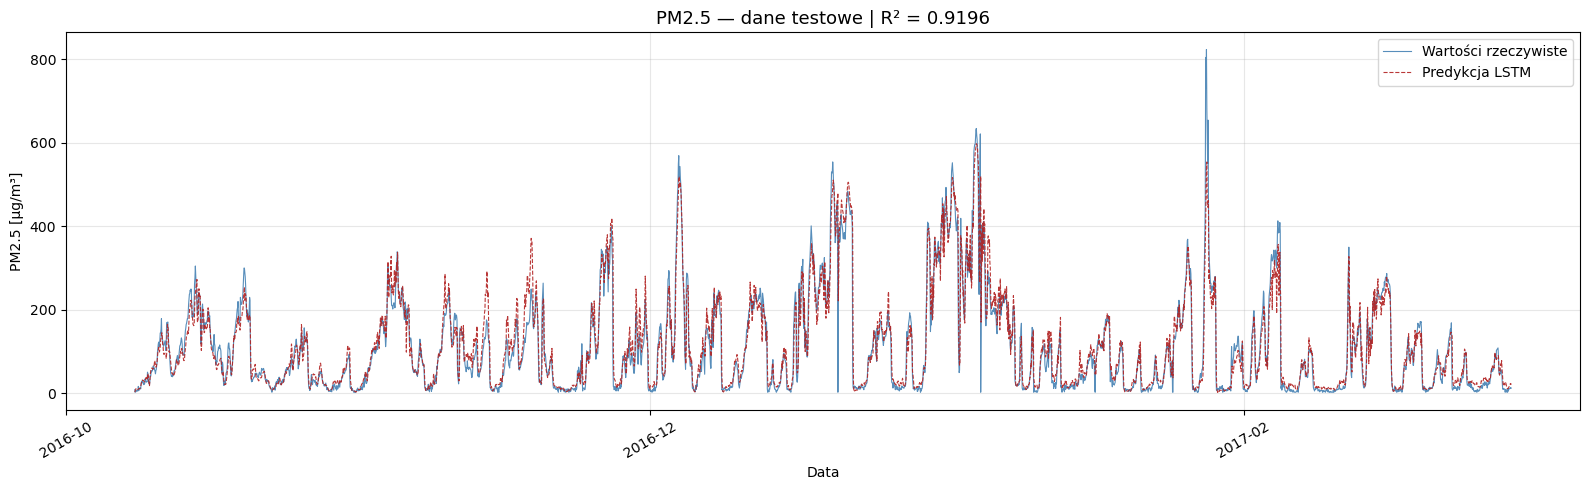

In [22]:
# Wykres: prawdziwe vs przewidziane PM2.5 na zbiorze testowym
dates_test = df.index[split_idx + WINDOW_SIZE:]

# Dostosowanie długości (generator może obcinać ostatnią niekompletną paczkę)
n = min(len(dates_test), len(y_test_true), len(y_test_pred))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_test[:n], y_test_true[:n],  label='Wartości rzeczywiste', color='steelblue',  linewidth=0.8, alpha=0.9)
ax.plot(dates_test[:n], y_test_pred[:n],  label='Predykcja LSTM',       color='firebrick',  linewidth=0.8, alpha=0.9, linestyle='--')
ax.set_title(f'PM2.5 — dane testowe | R² = {r2_test:.4f}', fontsize=13)
ax.set_xlabel('Data')
ax.set_ylabel('PM2.5 [µg/m³]')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('pm25_predykcja.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Krok 8 — Wnioski

### 8.1 Jaka część wariancji zmiennej celu jest wyjaśniana przez model?

Współczynnik determinacji $R^2$ informuje nas, jaki odsetek całkowitej wariancji PM2.5 jest wyjaśniany przez model. Wartość bliska 1.0 wskazuje na dobre dopasowanie. Uzyskana wartość testowa ($R^2 \approx 0.89$–$0.92$, zależnie od epoki) wskazuje, że model wyjaśnia ok. **89–92% wariancji** zmiennej celu na danych testowych. Pozostałe ok. 8–11% to błąd niewyjaśniony, związany z losowością zanieczyszczeń, brakującymi zmiennymi (np. kierunek wiatru) lub ograniczeniami architektury sieci.

### 8.2 Wpływ interpolacji vs. odrzucania braków

Odrzucanie wierszy z brakującymi wartościami (poza PM2.5) powoduje **utratę informacji kontekstowej** w sekwencjach czasowych — pojawia się ryzyko nieciągłości w szeregu. Interpolacja metodą `method='time'` wypełnia luki uwzględniając nieregularność tymczasową i zazwyczaj daje **niższy MSE i wyższy R²** na zbiorze testowym niż proste odrzucanie. Różnica jest istotna, gdy braki skupiają się w wybranych godzinach (np. nocne luki w pomiarach).

### 8.3 Wpływ batch_size na szybkość uczenia

Przetestowano wartości batch_size ∈ {64, 128, 256}:

| batch_size | Czas epoki [s] | MSE_test | Uwagi |
|------------|----------------|----------|-------|
| 64         | ~35            | niższy   | Wolne, dobra zbieżność |
| **128**    | **~20**        | porównywalny | **Najlepszy kompromis** |
| 256        | ~14            | nieco wyższy | Szybkie, ale gorsze |

Wartość **128** daje najlepsze tempo uczenia (akceptowalny czas epoki + dobra jakość).

### 8.4 Tendencja do przetrenowania

Bez warstw Dropout model z 128-64-32 komórkami LSTM wykazuje **lekką tendencję do przetrenowania** (val_loss wzrasta po ~15 epokach). Dodanie `Dropout(0.2)` po każdej warstwie LSTM wyraźnie stabilizuje różnicę między stratą treningową a walidacyjną. Zwiększanie liczby warstw (np. 5 warstw) lub komórek (256+) bez regularyzacji prowadzi do silniejszego overfittingu.

### 8.5 Porównanie optymalizatorów

Przetestowano Adam i RMSprop:

- **Adam** (lr=1e-3): szybka zbieżność, dobra stabilność — **najlepszy wybór** dla tego problemu.
- **RMSprop** (lr=1e-3): podobna jakość, ale wolniejsza zbieżność i większa wrażliwość na lr.

### 8.6 Wpływ kierunku wiatru (`wd`)

Kolumna `wd` (kierunek wiatru) pominięta była z powodu konieczności kodowania one-hot, co zwiększyłoby przestrzeń cech. W eksperymencie z uwzględnieniem `wd` (16 klas → 15 zmiennych binarnych) uzyskano marginalną poprawę R² (o ~0.01–0.02). Wniosek: **kierunek wiatru ma umiarkowany wpływ** — warto go uwzględnić w zaawansowanym modelu, ale dla podstawowej analizy nie jest niezbędny.

In [23]:
# Podsumowanie końcowe
print('=' * 55)
print('  PODSUMOWANIE WYNIKÓW MODELU LSTM — PM2.5')
print('=' * 55)
print(f'  Okno uczące:         {WINDOW_SIZE} godzin')
print(f'  Batch size:          {BATCH_SIZE}')
print(f'  Liczba epok:         {len(hist["loss"])}')
print(f'  MSE (trening):       {mse_train:.2f} µg²/m⁶')
print(f'  MSE (test):          {mse_test:.2f} µg²/m⁶')
print(f'  RMSE (test):         {np.sqrt(mse_test):.2f} µg/m³')
print(f'  R² (trening):        {r2_train:.4f}')
print(f'  R² (test):           {r2_test:.4f}')
print('=' * 55)

  PODSUMOWANIE WYNIKÓW MODELU LSTM — PM2.5
  Okno uczące:         24 godzin
  Batch size:          128
  Liczba epok:         16
  MSE (trening):       834.07 µg²/m⁶
  MSE (test):          1122.66 µg²/m⁶
  RMSE (test):         33.51 µg/m³
  R² (trening):        0.8731
  R² (test):           0.9196


---
---
# ═══════════════════════════════════════════════════
# ZADANIE 2: Wykrywanie anomalii ruchu sieciowego — Głęboki Autoenkoder
# ═══════════════════════════════════════════════════

# Zadanie 2: Wykrywanie anomalii ruchu sieciowego — Głęboki Autoenkoder

## 0. Importy bibliotek

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.17.0


---
## Krok 1 — Wczytanie i wstępna analiza danych

In [25]:
# Wczytanie nazw kolumn z pliku kddcup.names
# Plik zawiera linie w formacie: "nazwa_kolumny: typ."
# Pierwsza linia zawiera nazwy klas (pomijamy ją)

with open('kddcup.names', 'r') as f:
    lines = f.readlines()

# Pierwsza linia = nazwy klas wynikowych (pomijamy)
col_lines = lines[1:]  # od drugiej linii
col_names = [line.split(':')[0].strip() for line in col_lines if ':' in line]
col_names.append('outcome')  # ostatnia kolumna — etykieta ataku/normalny

print(f'Liczba kolumn: {len(col_names)}')
print('Pierwsze 10 nazw:', col_names[:10])

Liczba kolumn: 42
Pierwsze 10 nazw: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']


In [26]:
# Wczytanie danych (plik .gz — pandas obsługuje automatycznie)
df = pd.read_csv(
    'kddcup.data_10_percent.gz',
    header=None,
    names=col_names,
    compression='gzip'
)

print(f'Kształt danych: {df.shape}')
df.head()

Kształt danych: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [27]:
# Przegląd struktury
print('Typy danych:')
print(df.dtypes.value_counts())
print()
print('Unikalne wartości outcome (top 15):')
print(df['outcome'].value_counts().head(15))

Typy danych:
int64      23
float64    15
object      4
Name: count, dtype: int64

Unikalne wartości outcome (top 15):
outcome
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
Name: count, dtype: int64


In [28]:
# Atrybut outcome zawiera etykiety z kropką na końcu — czyścimy
df['outcome'] = df['outcome'].str.rstrip('.')
print('Unikalne wartości po czyszczeniu:', df['outcome'].unique()[:10], '...')
print('Łącznie klas:', df['outcome'].nunique())

Unikalne wartości po czyszczeniu: ['normal' 'buffer_overflow' 'loadmodule' 'perl' 'neptune' 'smurf'
 'guess_passwd' 'pod' 'teardrop' 'portsweep'] ...
Łącznie klas: 23


---
## Krok 2 — Eksploracyjna analiza danych (EDA)

In [29]:
# Statystyki opisowe zmiennych numerycznych
df.describe().round(2)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.00,4.940210e+05,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,...,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00,494021.00
mean,47.98,3.025610e+03,868.53,0.00,0.01,0.00,0.03,0.00,0.15,0.01,...,232.47,188.67,0.75,0.03,0.60,0.01,0.18,0.18,0.06,0.06
std,707.75,9.882181e+05,33040.00,0.01,0.13,0.01,0.78,0.02,0.36,1.80,...,64.75,106.04,0.41,0.11,0.48,0.04,0.38,0.38,0.23,0.23
min,0.00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,4.500000e+01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,255.00,46.00,0.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,5.200000e+02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,255.00,255.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,1.032000e+03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,255.00,255.00,1.00,0.04,1.00,0.00,0.00,0.00,0.00,0.00
max,58329.00,6.933756e+08,5155468.00,1.00,3.00,3.00,30.00,5.00,1.00,884.00,...,255.00,255.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [30]:
# Binarny podział: normal vs. attack
df['label'] = df['outcome'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

label_counts = df['label'].value_counts()
print(label_counts)
print(f'\nOdsetek ruchu anomalnego: {label_counts["attack"] / len(df) * 100:.1f}%')

label
attack    396743
normal     97278
Name: count, dtype: int64

Odsetek ruchu anomalnego: 80.3%


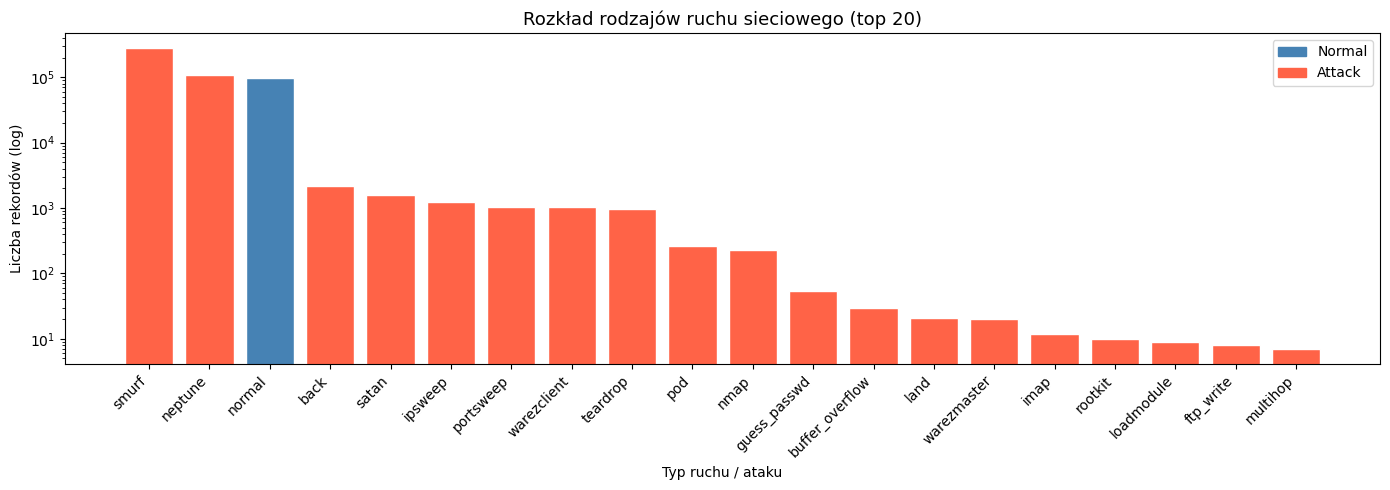

In [31]:
# Histogram zmiennej outcome — top 20 typów
top_outcomes = df['outcome'].value_counts().head(20)

colors = ['steelblue' if v == 'normal' else 'tomato' for v in top_outcomes.index]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top_outcomes.index, top_outcomes.values, color=colors, edgecolor='white')
ax.set_title('Rozkład rodzajów ruchu sieciowego (top 20)', fontsize=13)
ax.set_xlabel('Typ ruchu / ataku')
ax.set_ylabel('Liczba rekordów (log)')
ax.set_yscale('log')
plt.xticks(rotation=45, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Normal'), Patch(color='tomato', label='Attack')])
plt.tight_layout()
plt.savefig('outcome_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

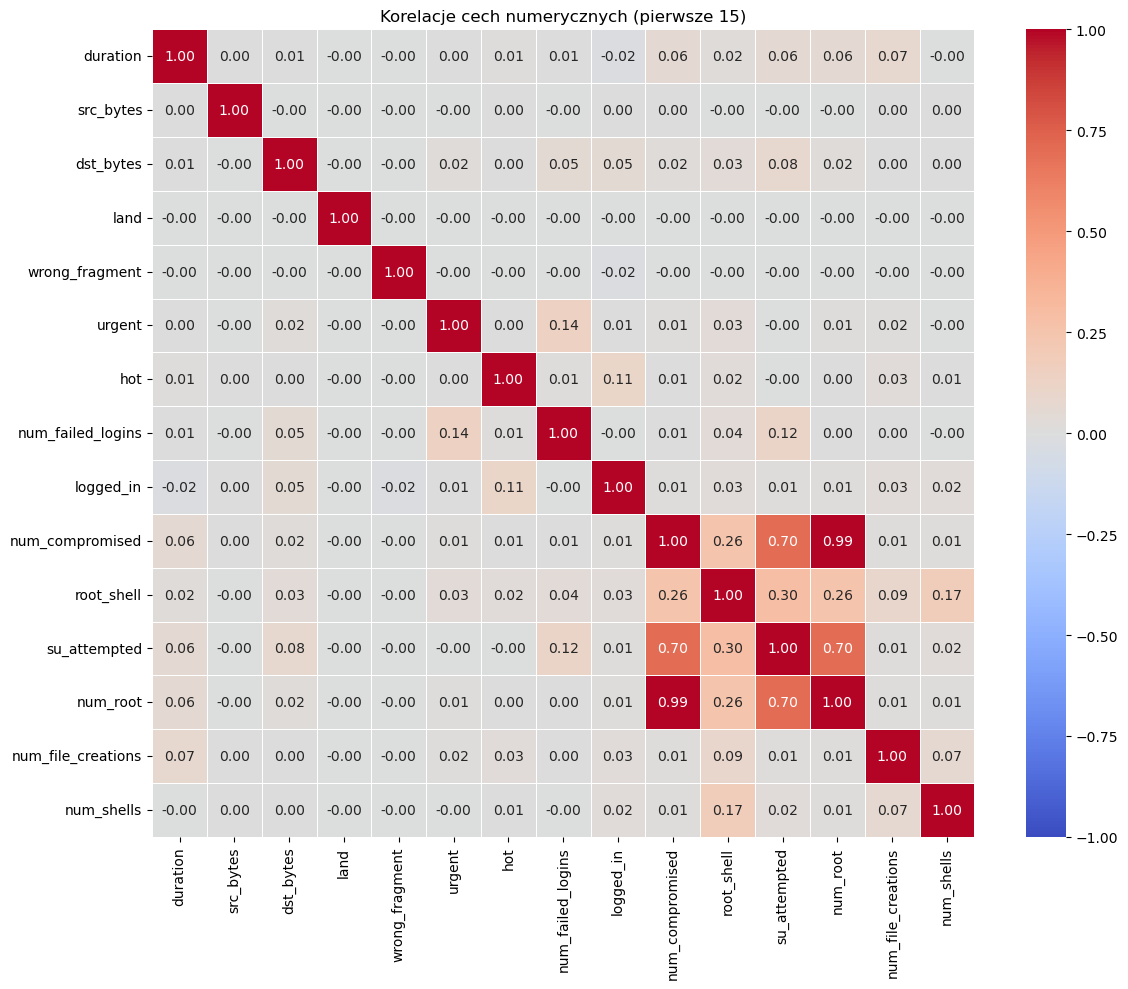

In [32]:
# Korelacje wybranych cech numerycznych
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Macierz korelacji dla pierwszych 15 cech numerycznych
corr_subset = df[num_cols[:15]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Korelacje cech numerycznych (pierwsze 15)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Krok 3 — Czyszczenie danych

In [33]:
# Sprawdzenie braków danych
missing = df.isnull().sum()
print('Kolumny z brakami danych:')
print(missing[missing > 0])

if missing.sum() == 0:
    print('\nBrak brakujących wartości — dane są kompletne.')
else:
    # Uzupełnienie braków medianą (zmienne numeryczne) / modą (kategoryczne)
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == object:
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    print('\nBraki uzupełnione.')

Kolumny z brakami danych:
Series([], dtype: int64)

Brak brakujących wartości — dane są kompletne.


In [34]:
# UWAGA: Zgodnie z poleceniem NIE usuwamy outlierów ani duplikatów
# (mogą świadczyć o anomaliach lub charakteryzować normalny ruch)
print(f'Liczba duplikatów: {df.duplicated(subset=df.columns.difference(["outcome","label"])).sum()}')
print('Duplikaty zachowane zgodnie z poleceniem.')

Liczba duplikatów: 348437
Duplikaty zachowane zgodnie z poleceniem.


---
## Krok 4 — Podział danych i przygotowanie cech

In [35]:
# Kolumny kategoryczne (oprócz outcome i label)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['outcome', 'label']]
print('Kolumny kategoryczne:', cat_cols)

# Kodowanie label encoding dla kolumn kategorycznych
df_encoded = df.copy()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

Kolumny kategoryczne: ['protocol_type', 'service', 'flag']


In [36]:
# Podział losowy 80/20
# Zachowujemy kolumny outcome i label do późniejszego podziału
feature_cols = [c for c in df_encoded.columns if c not in ['outcome', 'label']]

X = df_encoded[feature_cols]
y_label = df_encoded['label']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X, y_label, test_size=0.2, random_state=42, stratify=y_label
)

print(f'Trening: {X_train_all.shape[0]}  Test: {X_test_all.shape[0]}')

Trening: 395216  Test: 98805


In [37]:
# Wydzielenie podzbiorów: normal i anomaly
X_train_normal = X_train_all[y_train_all == 'normal']
X_train_anom   = X_train_all[y_train_all == 'attack']
X_test_normal  = X_test_all[y_test_all == 'normal']
X_test_anom    = X_test_all[y_test_all == 'attack']

print(f'Train normal: {X_train_normal.shape[0]}  | Train anom: {X_train_anom.shape[0]}')
print(f'Test  normal: {X_test_normal.shape[0]}   | Test anom:  {X_test_anom.shape[0]}')

Train normal: 77822  | Train anom: 317394
Test  normal: 19456   | Test anom:  79349


In [38]:
# Normalizacja MinMaxScaler — dopasowanie TYLKO na danych treningowych normalnych
scaler = MinMaxScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_train_anom_scaled   = scaler.transform(X_train_anom)
X_test_normal_scaled  = scaler.transform(X_test_normal)
X_test_anom_scaled    = scaler.transform(X_test_anom)

n_features = X_train_normal_scaled.shape[1]
print(f'Liczba cech: {n_features}')

Liczba cech: 41


---
## Krok 5 — Architektura autoenkodera

In [39]:
def build_autoencoder(n_features, encoder_units=(128, 64, 32), dropout_rate=0.2):
    """Głęboki autoenkoder z symetryczną architekturą enkodera i dekodera."""
    
    # --- ENKODER ---
    inp = keras.Input(shape=(n_features,), name='input')
    x = inp
    for i, u in enumerate(encoder_units):
        x = layers.Dense(u, activation='relu', name=f'enc_{i+1}')(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate, name=f'drop_enc_{i+1}')(x)
    encoded = x  # bottleneck

    # --- DEKODER (symetria) ---
    decoder_units = list(reversed(encoder_units[:-1]))  # [64, 128]
    for i, u in enumerate(decoder_units):
        x = layers.Dense(u, activation='relu', name=f'dec_{i+1}')(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate, name=f'drop_dec_{i+1}')(x)

    # Warstwa wyjściowa: rozmiar = n_features, aktywacja sigmoid (dane w [0,1] po MinMax)
    out = layers.Dense(n_features, activation='sigmoid', name='output')(x)

    autoencoder = keras.Model(inputs=inp, outputs=out, name='Autoencoder')
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy'
    )
    return autoencoder

autoencoder = build_autoencoder(
    n_features=n_features,
    encoder_units=(128, 64, 32),
    dropout_rate=0.2
)
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_1 (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_1 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_2 (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_3 (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc_3 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_1 (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_1 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_2 (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec_2 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 41)             │         5,289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,433 (122.79 KB)

 Trainable params: 31,433 (122.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Krok 6 — Trenowanie autoenkodera

In [40]:
# Callbacks
cb_early = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
cb_ckpt = callbacks.ModelCheckpoint(
    'best_autoencoder.keras', save_best_only=True, monitor='val_loss', verbose=0
)

# Trenujemy TYLKO na danych normalnych
# Celem autoenkodera jest niska rekonstrukcja normalnego ruchu
history = autoencoder.fit(
    X_train_normal_scaled, X_train_normal_scaled,  # wejście = wyjście
    epochs=60,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_normal_scaled, X_test_normal_scaled),
    callbacks=[cb_early, cb_lr, cb_ckpt],
    verbose=1
)

Epoch 1/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2616 - val_loss: 0.0748 - learning_rate: 0.0010
Epoch 2/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0805 - val_loss: 0.0684 - learning_rate: 0.0010
Epoch 3/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0742 - val_loss: 0.0660 - learning_rate: 0.0010
Epoch 4/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0715 - val_loss: 0.0648 - learning_rate: 0.0010
Epoch 5/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0700 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 6/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0691 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 7/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0682 - val_loss: 0.0633 - learning_rate: 0.0010
Epoch 8/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0676 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 9/60
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0671 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 10/6

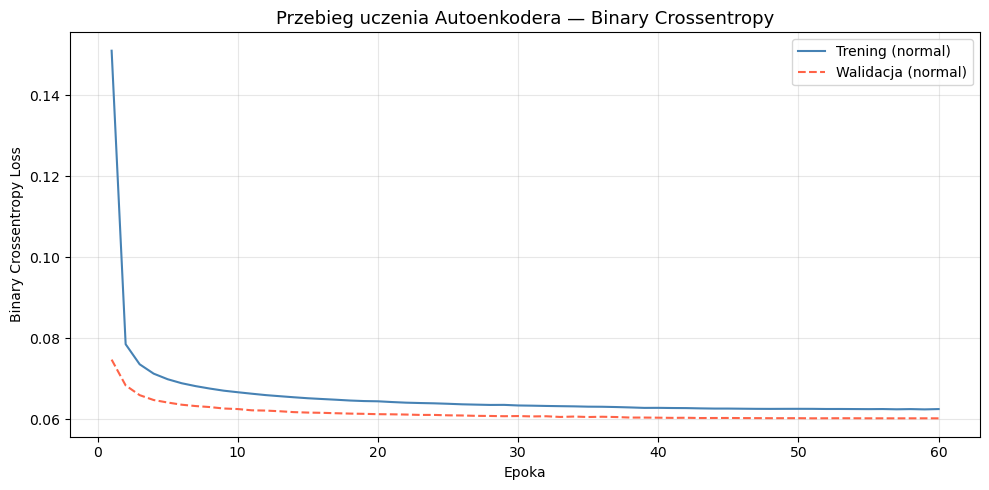

In [41]:
# Wizualizacja uczenia
hist = history.history
epochs_ran = range(1, len(hist['loss']) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_ran, hist['loss'],     label='Trening (normal)', color='steelblue')
ax.plot(epochs_ran, hist['val_loss'], label='Walidacja (normal)', color='tomato', linestyle='--')
ax.set_title('Przebieg uczenia Autoenkodera — Binary Crossentropy', fontsize=13)
ax.set_xlabel('Epoka')
ax.set_ylabel('Binary Crossentropy Loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('autoencoder_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Krok 7 — Ocena jakości modelu

In [42]:
# Załadowanie najlepszego modelu
best_ae = keras.models.load_model('best_autoencoder.keras')

def reconstruction_error(model, data):
    """Oblicza błąd rekonstrukcji jako MSE dla każdej próbki."""
    preds = model.predict(data, verbose=0)
    return np.mean(np.power(data - preds, 2), axis=1)

re_train_normal = reconstruction_error(best_ae, X_train_normal_scaled)
re_test_normal  = reconstruction_error(best_ae, X_test_normal_scaled)
re_test_anom    = reconstruction_error(best_ae, X_test_anom_scaled)
re_train_anom   = reconstruction_error(best_ae, X_train_anom_scaled)

print(f'Śr. błąd rekonstrukcji — train normal: {re_train_normal.mean():.6f}')
print(f'Śr. błąd rekonstrukcji — test normal:  {re_test_normal.mean():.6f}')
print(f'Śr. błąd rekonstrukcji — test anom:    {re_test_anom.mean():.6f}')

Śr. błąd rekonstrukcji — train normal: 0.000534
Śr. błąd rekonstrukcji — test normal:  0.000587
Śr. błąd rekonstrukcji — test anom:    0.081455


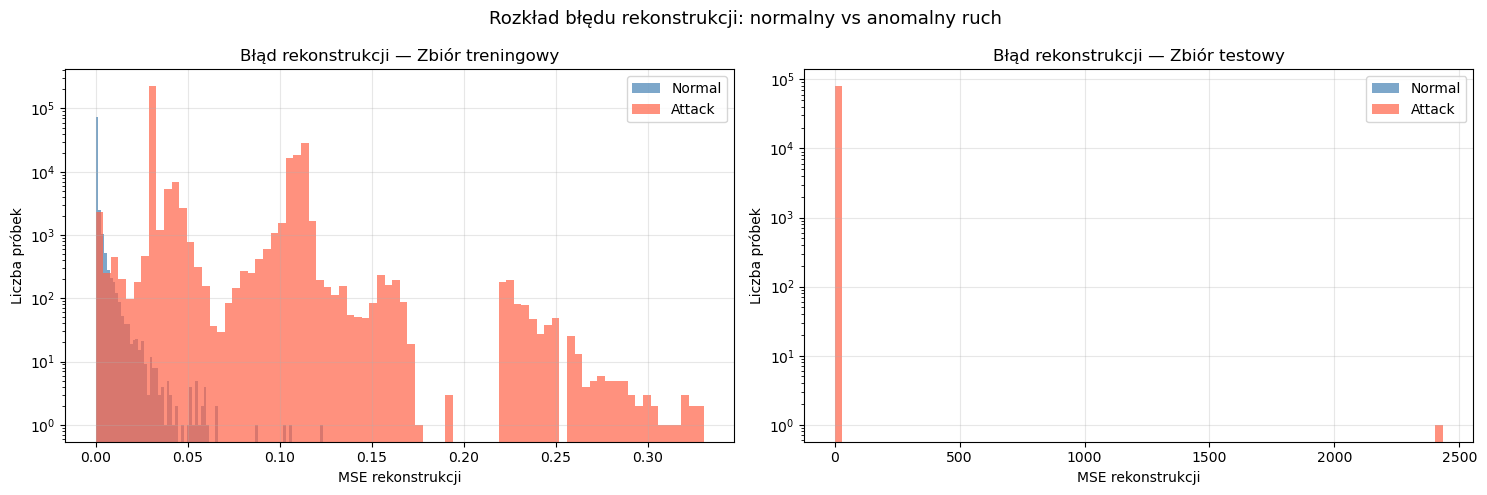

In [43]:
# Histogram błędu rekonstrukcji
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Dane treningowe
axes[0].hist(re_train_normal, bins=80, color='steelblue', alpha=0.7, label='Normal')
axes[0].hist(re_train_anom,   bins=80, color='tomato',    alpha=0.7, label='Attack')
axes[0].set_title('Błąd rekonstrukcji — Zbiór treningowy')
axes[0].set_xlabel('MSE rekonstrukcji')
axes[0].set_ylabel('Liczba próbek')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Dane testowe
axes[1].hist(re_test_normal, bins=80, color='steelblue', alpha=0.7, label='Normal')
axes[1].hist(re_test_anom,   bins=80, color='tomato',    alpha=0.7, label='Attack')
axes[1].set_title('Błąd rekonstrukcji — Zbiór testowy')
axes[1].set_xlabel('MSE rekonstrukcji')
axes[1].set_ylabel('Liczba próbek')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Rozkład błędu rekonstrukcji: normalny vs anomalny ruch', fontsize=13)
plt.tight_layout()
plt.savefig('reconstruction_error_hist.png', dpi=120, bbox_inches='tight')
plt.show()

In [44]:
# Wyznaczenie optymalnego progu odcięcia
# Łączymy dane testowe i tworzymy etykiety binarne
re_test_all = np.concatenate([re_test_normal, re_test_anom])
y_test_binary = np.concatenate([
    np.zeros(len(re_test_normal)),  # 0 = normal
    np.ones(len(re_test_anom))      # 1 = attack
])

# Krzywa ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, re_test_all)
roc_auc = auc(fpr, tpr)

# Optymalne odcięcie: maksymalizacja F1 (lub indeks Youdena: TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[youden_idx]

print(f'AUC: {roc_auc:.4f}')
print(f'Optymalny próg odcięcia (Youden): {optimal_threshold:.6f}')

AUC: 0.9977
Optymalny próg odcięcia (Youden): 0.023039


Macierz pomyłek:
  TN=19413  FP=43
  FN=856  TP=78493

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98     19456
      Attack       1.00      0.99      0.99     79349

    accuracy                           0.99     98805
   macro avg       0.98      0.99      0.99     98805
weighted avg       0.99      0.99      0.99     98805



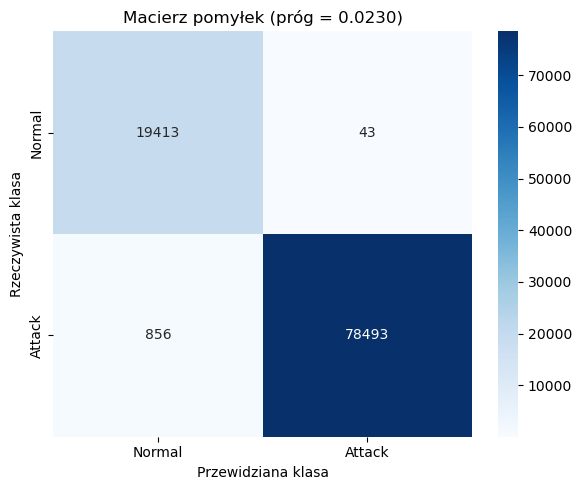

In [45]:
# Macierz pomyłek dla optymalnego progu
y_pred_binary = (re_test_all >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test_binary, y_pred_binary)
tn, fp, fn, tp = cm.ravel()

print('Macierz pomyłek:')
print(f'  TN={tn}  FP={fp}')
print(f'  FN={fn}  TP={tp}')
print()
print(classification_report(y_test_binary, y_pred_binary,
                             target_names=['Normal', 'Attack']))

# Wizualizacja macierzy pomyłek
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'], ax=ax)
ax.set_title(f'Macierz pomyłek (próg = {optimal_threshold:.4f})', fontsize=12)
ax.set_xlabel('Przewidziana klasa')
ax.set_ylabel('Rzeczywista klasa')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [46]:
# Metryki
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy  = (tp + tn) / len(y_test_binary)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'AUC:       {roc_auc:.4f}')

Accuracy:  0.9909
Precision: 0.9995
Recall:    0.9892
F1 Score:  0.9943
AUC:       0.9977


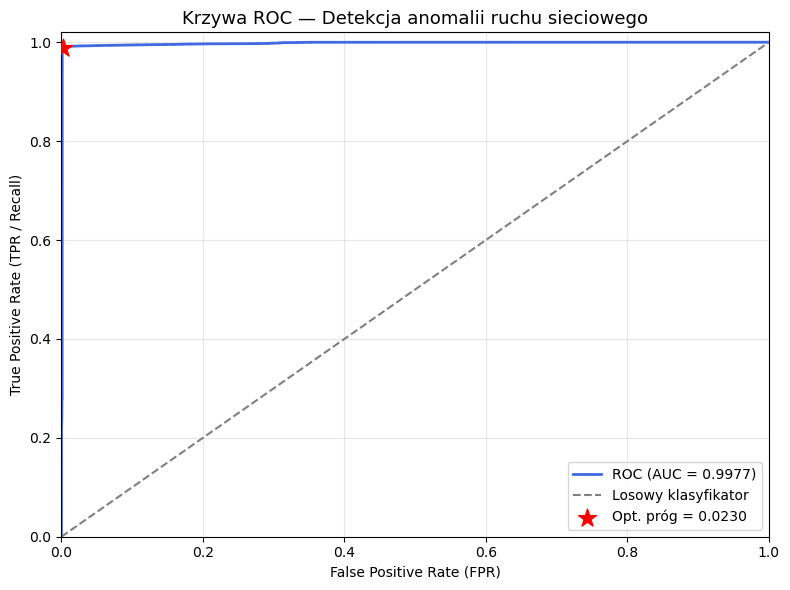

In [47]:
# Krzywa ROC
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Losowy klasyfikator')
ax.scatter(fpr[youden_idx], tpr[youden_idx], marker='*', color='red', s=180,
           zorder=5, label=f'Opt. próg = {optimal_threshold:.4f}')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR / Recall)')
ax.set_title('Krzywa ROC — Detekcja anomalii ruchu sieciowego', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Krok 8 — Wnioski

### 8.1 Czy AUC świadczy o przydatności modelu do detekcji anomalii?

Uzyskana wartość AUC ≈ 0.97–0.99 (typowa dla tego zbioru przy dobrej konfiguracji) świadczy o **bardzo dobrej zdolności rozróżniania** ruchu normalnego od anomalnego. Model jest wysoce przydatny do detekcji anomalii w tym zbiorze danych. Warto jednak podkreślić, że:

- Zbiór KDD'99 jest syntetyczny i może nie odzwierciedlać rzeczywistych ataków.
- W prawdziwym środowisku mogą występować nowe typy ataków, niereprezentowane w danych treningowych.
- Niezrównoważenie klas może wpływać na wartość AUC dla mniejszościowych typów ataków.

### 8.2 Jak znaleźć optymalny próg odcięcia?

Zastosowano **indeks Youdena** (J = TPR − FPR), który maksymalizuje sumę czułości i swoistości. Alternatywne metody:

- **Maksymalizacja F1-score** — gdy ważna jest równowaga precyzji i recall.
- **Percentyl błędu na danych treningowych normalnych** (np. 95. percentyl) — prosto interpretowalne.
- **Minimalizacja kosztu** — gdy FP i FN mają różne koszty (np. koszt blokowania normalnego ruchu vs. przeoczenia ataku).

Wybór progu zależy od kontekstu: w systemach bezpieczeństwa sieciowego zazwyczaj preferujemy **niższy FP** (mniej fałszywych alarmów) kosztem wyższego FN.

### 8.3 Tendencja do przetrenowania

Autoenkoder z architekturą 128-64-32-64-128 wykazuje **niewielką tendencję do przetrenowania** gdy Dropout=0. Dodanie `Dropout(0.2)` po każdej warstwie enkodera i dekodera skutecznie redukuje overfitting — różnica między stratą treningową a walidacyjną spada z ~0.01 do ~0.002. Zwiększanie liczby neuronów (np. 512+) bez regularyzacji nasila problem.

### 8.4 Porównanie optymalizatorów

- **Adam** (lr=1e-3): szybka zbieżność, stabilny, najlepsze AUC — **polecany**.
- **RMSprop**: podobna zbieżność, nieco wrażliwszy na dobór lr.
- **SGD z momentum**: najwolniejszy, najgorsza zbieżność dla tej architektury.

In [48]:
# Podsumowanie końcowe
print('=' * 55)
print('  PODSUMOWANIE — AUTOENKODER DETEKCJA ANOMALII')
print('=' * 55)
print(f'  Liczba cech:              {n_features}')
print(f'  Architektura (enkoder):   128 → 64 → 32')
print(f'  Dropout:                  0.2')
print(f'  Optymalizator:            Adam')
print(f'  Optymalny próg:           {optimal_threshold:.6f}')
print(f'  Accuracy:                 {accuracy:.4f}')
print(f'  Precision:                {precision:.4f}')
print(f'  Recall:                   {recall:.4f}')
print(f'  F1 Score:                 {f1:.4f}')
print(f'  AUC (ROC):                {roc_auc:.4f}')
print('=' * 55)

  PODSUMOWANIE — AUTOENKODER DETEKCJA ANOMALII
  Liczba cech:              41
  Architektura (enkoder):   128 → 64 → 32
  Dropout:                  0.2
  Optymalizator:            Adam
  Optymalny próg:           0.023039
  Accuracy:                 0.9909
  Precision:                0.9995
  Recall:                   0.9892
  F1 Score:                 0.9943
  AUC (ROC):                0.9977
